# 02 — Clip DEM

Download and clip the USGS 3DEP 10m DEM to the Emerald Triangle study extent.

10m resolution is sufficient at 2km hex spacing — zonal stats will average
hundreds of pixels per cell anyway.

**Source:** USGS National Map 3DEP 10m (1/3 arc-second)  
**API:** USGS TNM Download API (no key required)

**Outputs:**
- `data/raw/dem_emerald.tif` — clipped, UTM 10N DEM

In [1]:
from pathlib import Path
import requests
import json as _json
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.merge import merge
from rasterio.mask import mask as rio_mask
from rasterio.warp import calculate_default_transform, reproject, Resampling
import matplotlib.pyplot as plt
from shapely.ops import unary_union

RAW = Path('../data/raw')
IMG = Path('../img')

/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


## 1. Load study extent

In [2]:
study_area = gpd.read_file(RAW / 'study_area.gpkg')
# USGS TNM API expects WGS84
study_wgs84 = study_area.to_crs('EPSG:4326')
bounds = study_wgs84.total_bounds  # xmin, ymin, xmax, ymax
print(f'Extent (WGS84): {bounds.round(4)}')

Extent (WGS84): [-124.5056   38.7401 -122.4216   41.4839]


## 2. Query USGS TNM API for 3DEP 10m tiles

In [3]:
from pathlib import Path

TNM_URL = 'https://tnmaccess.nationalmap.gov/api/v1/products'

params = {
    'datasets':     'National Elevation Dataset (NED) 1 arc-second',
    'bbox':         f'{bounds[0]},{bounds[1]},{bounds[2]},{bounds[3]}',
    'outputFormat': 'JSON',
    'max':          100,
}

r = requests.get(TNM_URL, params=params, timeout=60)
r.raise_for_status()
items = r.json().get('items', [])

best = {}
for it in items:
    url = it.get('downloadURL', '')
    if not url.lower().endswith('.tif'):
        continue
    name = Path(url).stem
    parts = name.split('_')
    if len(parts) < 4:
        continue
    tile_key = '_'.join(parts[:3])
    date_str = parts[3]
    if tile_key not in best or date_str > best[tile_key][0]:
        best[tile_key] = (date_str, url)

tile_urls = [v[1] for v in best.values()]
print(f'1 arc-second tiles (latest vintage): {len(tile_urls)}')
for u in sorted(tile_urls):
    print(' ', Path(u).name)

1 arc-second tiles (latest vintage): 11
  USGS_1_n39w123_20250520.tif
  USGS_1_n39w124_20250520.tif
  USGS_1_n40w123_20250520.tif
  USGS_1_n40w124_20250520.tif
  USGS_1_n40w125_20200121.tif
  USGS_1_n41w123_20250520.tif
  USGS_1_n41w124_20250520.tif
  USGS_1_n41w125_20240313.tif
  USGS_1_n42w123_20260202.tif
  USGS_1_n42w124_20250812.tif
  USGS_1_n42w125_20250812.tif


In [4]:
import rasterio

TILE_DIR = RAW / 'dem_tiles_1arc'
TILE_DIR.mkdir(exist_ok=True)

tile_paths = []
for i, url in enumerate(tile_urls):
    fname = TILE_DIR / Path(url).name
    if fname.exists():
        try:
            with rasterio.open(fname) as src:
                src.read(1, window=rasterio.windows.Window(0, 0, 1, 1))
            print(f'  [{i+1}/{len(tile_urls)}] ok       {fname.name}')
            tile_paths.append(fname)
            continue
        except Exception:
            print(f'  [{i+1}/{len(tile_urls)}] corrupt — re-downloading')
            fname.unlink()

    print(f'  [{i+1}/{len(tile_urls)}] downloading {fname.name} ...')
    r = requests.get(url, timeout=300, stream=True)
    r.raise_for_status()
    with open(fname, 'wb') as f:
        for chunk in r.iter_content(1 << 20):
            f.write(chunk)
    print(f'      {fname.stat().st_size / 1e6:.1f} MB')
    tile_paths.append(fname)

print(f'\n{len(tile_paths)} tiles ready')

  [1/11] ok       USGS_1_n39w123_20250520.tif
  [2/11] ok       USGS_1_n39w124_20250520.tif
  [3/11] ok       USGS_1_n40w123_20250520.tif
  [4/11] ok       USGS_1_n40w124_20250520.tif
  [5/11] ok       USGS_1_n41w123_20250520.tif
  [6/11] ok       USGS_1_n41w124_20250520.tif
  [7/11] ok       USGS_1_n41w125_20240313.tif
  [8/11] ok       USGS_1_n42w123_20260202.tif
  [9/11] ok       USGS_1_n42w124_20250812.tif
  [10/11] ok       USGS_1_n42w125_20250812.tif
  [11/11] ok       USGS_1_n40w125_20200121.tif

11 tiles ready


## 3. Merge tiles and clip to study extent

In [5]:
import subprocess

OUT_DEM  = RAW / 'dem_emerald.tif'
VRT      = RAW / 'dem_tiles_1arc' / 'mosaic.vrt'
CUTLINE  = RAW / 'emerald_counties.gpkg'

# Build VRT — lightweight XML index, no data in memory
print('Building VRT...')
subprocess.run(
    ['gdalbuildvrt', str(VRT)] + [str(p) for p in tile_paths],
    check=True, capture_output=True
)

# Clip to county shapes + reproject in one streaming pass
bounds_utm = study_area.total_bounds
print('Warping to UTM 10N and clipping to county boundaries...')
result = subprocess.run([
    'gdalwarp',
    '-t_srs',      'EPSG:32610',
    '-te',         str(bounds_utm[0]), str(bounds_utm[1]),
                   str(bounds_utm[2]), str(bounds_utm[3]),
    '-tr',         '30', '30',
    '-r',          'bilinear',
    '-cutline',    str(CUTLINE),
    '-crop_to_cutline',
    '-dstnodata',  '-9999',
    '-co',         'COMPRESS=LZW',
    '-co',         'TILED=YES',
    str(VRT), str(OUT_DEM),
], check=True, capture_output=True)

print(f'Saved {OUT_DEM}  ({OUT_DEM.stat().st_size / 1e6:.0f} MB)')

with rasterio.open(OUT_DEM) as src:
    print(f'CRS:        {src.crs}')
    print(f'Resolution: {src.res} m')
    print(f'Shape:      {src.shape}')
    print(f'Bounds:     {src.bounds}')

Building VRT...
Warping to UTM 10N and clipping to county boundaries...
Saved ../data/raw/dem_emerald.tif  (130 MB)
CRS:        EPSG:32610
Resolution: (30.0, 30.0) m
Shape:      (10028, 5741)
Bounds:     BoundingBox(left=374310.70232601487, bottom=4290101.111189965, right=546540.7023260149, top=4590941.111189965)


## 4. Quick map

In [8]:
emerald = gpd.read_file(RAW / 'emerald_counties.gpkg')

with rasterio.open(OUT_DEM) as src:
    data = src.read(1).astype(float)
    data[data == src.nodata] = np.nan
    extent = [src.bounds.left, src.bounds.right,
              src.bounds.bottom, src.bounds.top]

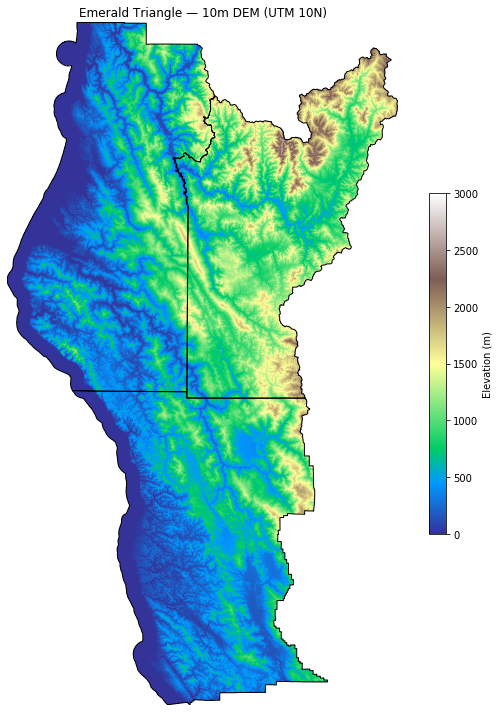

Saved img/02_dem.png


In [10]:
fig, ax = plt.subplots(figsize=(9, 10))
im = ax.imshow(data, extent=extent, cmap='terrain',
               vmin=np.nanpercentile(data, 2),
               vmax=3000)
emerald.boundary.plot(ax=ax, edgecolor='k', linewidth=1)
plt.colorbar(im, ax=ax, label='Elevation (m)', shrink=0.5)
ax.set_title('Emerald Triangle — 10m DEM (UTM 10N)', fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('../img/02_dem.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved img/02_dem.png')